# 🔬 Retail Store Inventory Forecasting — Advanced Feature Engineering

**Objective:** Build a second round of advanced, domain-driven features on top of the existing engineered dataset to push model performance further — *before* investing in hyperparameter tuning.

**Why another feature-engineering pass?**  
The baseline models (Notebook 05) established performance floors. Instead of immediately tuning hyperparameters, we first squeeze more predictive signal out of the data — this is almost always a higher-ROI activity. New features capture **business-level interactions** (e.g., how pricing relates to inventory depth, or how promotions and discounts work together) that individual raw columns cannot express.

---

### New Features to Create

| # | Feature | Formula | Business Rationale |
|---|---------|---------|--------------------|
| 1 | `INVENTORY_UTILIZATION` | Units Ordered / (Inventory Level + 1) | How aggressively is stock being replenished relative to what's on-hand? |
| 2 | `PRICE_COMPETITIVENESS` | Price / (Competitor Pricing + 1) | Ratio measuring our price relative to the competitor — >1 = we're pricier |
| 3 | `PROMOTION_STRENGTH` | Discount × Holiday/Promotion | Combined promotional firepower — discounts during promotions are amplified |
| 4 | `CATEGORY_SEASON` | Category + "_" + Seasonality | Captures category-specific seasonal buying patterns |
| 5 | `CATEGORY_WEATHER` | Category + "_" + Weather Condition | Captures category-specific weather-driven demand |
| 6 | `PRICE_PER_INVENTORY` | Price / (Inventory Level + 1) | High-priced items with low stock = premium scarcity |
| 7 | `DISCOUNT_PRICE_RATIO` | Discount / (Price + 1) | How significant is the discount relative to the item's price? |
| 8 | `INVENTORY_VALUE` | Inventory Level × Price | Total monetary value of on-hand stock for a product |
| 9 | `COMPETITOR_PRICE_DIFF_PERCENT` | ((Price − Competitor Pricing) / (Competitor Pricing + 1)) × 100 | Percentage price premium or discount vs. competitor |

---

**This notebook covers:**
1. Import Libraries & Load Data
2. Create Advanced Features
3. Display & Verify New Features
4. Correlation Analysis with Target (`Units Sold`)
5. Correlation Visualisations
6. Compare New vs. Previously Engineered Features
7. Top Positive & Negative Correlated Features
8. Feature Importance via Quick Random Forest
9. Business Interpretations
10. Feature Retention Recommendations
11. Save Final Dataset & Conclusions

---
## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Plotting style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.facecolor': '#f8f9fa',
    'figure.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Load the feature-engineered dataset from Notebook 04
df = pd.read_csv('feature_engineered_retail_inventory.csv')

print(f'✅ Dataset loaded successfully.')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Target: Units Sold')
print(f'\nExisting columns ({df.shape[1]}):')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

df.head()

✅ Dataset loaded successfully.
   Shape: 73,100 rows × 31 columns
   Target: Units Sold

Existing columns (31):
   1. Store ID
   2. Product ID
   3. Category
   4. Region
   5. Inventory Level
   6. Units Sold
   7. Units Ordered
   8. Price
   9. Discount
  10. Weather Condition
  11. Holiday/Promotion
  12. Competitor Pricing
  13. Seasonality
  14. Year
  15. Month
  16. Day
  17. DayOfWeek
  18. Quarter
  19. IsWeekend
  20. PRICE_DIFF
  21. PRICE_RATIO
  22. DISCOUNTED_PRICE
  23. INVENTORY_COVERAGE
  24. STOCK_GAP
  25. PROMO_DISCOUNT
  26. HIGH_DISCOUNT_FLAG
  27. COMPETITOR_CHEAPER
  28. MONTH_SIN
  29. MONTH_COS
  30. DOW_SIN
  31. DOW_COS


,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,...,DISCOUNTED_PRICE,INVENTORY_COVERAGE,STOCK_GAP,PROMO_DISCOUNT,HIGH_DISCOUNT_FLAG,COMPETITOR_CHEAPER,MONTH_SIN,MONTH_COS,DOW_SIN,DOW_COS
0,0,0,3,1,231,127,55,33.50,20,1,...,26.800,4.125000,176,0,1,1,0.5,0.866025,-0.974928,-0.222521
1,0,1,4,2,204,150,66,63.01,20,3,...,50.408,3.044776,138,0,1,0,0.5,0.866025,-0.974928,-0.222521
2,0,2,4,3,102,65,51,27.99,10,3,...,25.191,1.961538,51,10,0,0,0.5,0.866025,-0.974928,-0.222521
3,0,3,4,1,469,61,164,32.72,10,0,...,29.448,2.842424,305,10,0,0,0.5,0.866025,-0.974928,-0.222521
4,0,4,1,0,166,14,135,73.64,0,3,...,73.640,1.220588,31,0,0,1,0.5,0.866025,-0.974928,-0.222521


---
## 2. Create Advanced Features

Each feature below is motivated by **retail domain knowledge** — capturing relationships that raw columns alone cannot express. The `+ 1` denominators prevent division-by-zero errors.

In [2]:
# ─── 2a. INVENTORY_UTILIZATION ───
# How aggressively is stock being replenished vs. current on-hand inventory?
# High values indicate lean inventory with aggressive ordering (just-in-time).
# Low values indicate overstocking or cautious replenishment.
df['INVENTORY_UTILIZATION'] = df['Units Ordered'] / (df['Inventory Level'] + 1)

# ─── 2b. PRICE_COMPETITIVENESS ───
# Our price relative to competitor's. Values > 1 mean we are more expensive.
# This is a continuous competitiveness signal that complements the binary COMPETITOR_CHEAPER flag.
df['PRICE_COMPETITIVENESS'] = df['Price'] / (df['Competitor Pricing'] + 1)

# ─── 2c. PROMOTION_STRENGTH ───
# The combined effect of a discount AND a holiday/promotion event.
# A 20% discount on a normal day vs. 20% discount during a holiday have very different impacts.
df['PROMOTION_STRENGTH'] = df['Discount'] * df['Holiday/Promotion']

# ─── 2d. CATEGORY_SEASON (Interaction Feature) ───
# Different product categories behave differently across seasons.
# e.g., "Electronics" in Winter vs. "Clothing" in Summer have unique demand patterns.
df['CATEGORY_SEASON'] = df['Category'].astype(str) + '_' + df['Seasonality'].astype(str)

# ─── 2e. CATEGORY_WEATHER (Interaction Feature) ───
# Weather impacts categories differently — umbrellas sell in rain, ice cream in sun.
df['CATEGORY_WEATHER'] = df['Category'].astype(str) + '_' + df['Weather Condition'].astype(str)

# ─── 2f. PRICE_PER_INVENTORY ───
# Price per unit of inventory — captures the "premium scarcity" effect.
# High value = expensive items with limited stock (luxury/niche signal).
df['PRICE_PER_INVENTORY'] = df['Price'] / (df['Inventory Level'] + 1)

# ─── 2g. DISCOUNT_PRICE_RATIO ───
# How significant is the discount relative to the product's price?
# A $5 discount on a $10 item is very different from $5 off a $100 item.
df['DISCOUNT_PRICE_RATIO'] = df['Discount'] / (df['Price'] + 1)

# ─── 2h. INVENTORY_VALUE ───
# Total monetary value of on-hand stock — proxy for capital tied up in inventory.
# Stores may push harder to sell high-value inventory to free up capital.
df['INVENTORY_VALUE'] = df['Inventory Level'] * df['Price']

# ─── 2i. COMPETITOR_PRICE_DIFF_PERCENT ───
# Percentage by which our price exceeds (or undercuts) the competitor.
# Positive = we charge more; Negative = we undercut the competitor.
df['COMPETITOR_PRICE_DIFF_PERCENT'] = (
    (df['Price'] - df['Competitor Pricing']) / (df['Competitor Pricing'] + 1)
) * 100

print('✅ All 9 advanced features created successfully!')
print(f'   Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ All 9 advanced features created successfully!
   Dataset shape: 73,100 rows × 40 columns


In [3]:
# ─── 2j. Label-encode the categorical interaction features ───
# CATEGORY_SEASON and CATEGORY_WEATHER are string columns — we need numeric form for ML.

le_season  = LabelEncoder()
le_weather = LabelEncoder()

df['CATEGORY_SEASON_ENC']  = le_season.fit_transform(df['CATEGORY_SEASON'])
df['CATEGORY_WEATHER_ENC'] = le_weather.fit_transform(df['CATEGORY_WEATHER'])

print('✅ Categorical interaction features label-encoded.')
print(f'   CATEGORY_SEASON  → {le_season.classes_.shape[0]} unique classes')
print(f'   CATEGORY_WEATHER → {le_weather.classes_.shape[0]} unique classes')

print(f'\nSample mappings (CATEGORY_SEASON):')
for cls, enc in zip(le_season.classes_[:8], range(8)):
    print(f'   {cls} → {enc}')

✅ Categorical interaction features label-encoded.
   CATEGORY_SEASON  → 20 unique classes
   CATEGORY_WEATHER → 20 unique classes

Sample mappings (CATEGORY_SEASON):
   0_0 → 0
   0_1 → 1
   0_2 → 2
   0_3 → 3
   1_0 → 4
   1_1 → 5
   1_2 → 6
   1_3 → 7


---
## 3. Display & Verify New Features

Let's inspect the newly created features to confirm correctness and spot any anomalies.

In [4]:
# List of all advanced features (numeric only — used for analysis)
advanced_features = [
    'INVENTORY_UTILIZATION',
    'PRICE_COMPETITIVENESS',
    'PROMOTION_STRENGTH',
    'CATEGORY_SEASON_ENC',
    'CATEGORY_WEATHER_ENC',
    'PRICE_PER_INVENTORY',
    'DISCOUNT_PRICE_RATIO',
    'INVENTORY_VALUE',
    'COMPETITOR_PRICE_DIFF_PERCENT'
]

print(f'=== Advanced Features Created: {len(advanced_features)} ===\n')
for i, feat in enumerate(advanced_features, 1):
    print(f'  {i}. {feat}')

print(f'\n=== Summary Statistics ===\n')
df[advanced_features].describe().T.round(4)

=== Advanced Features Created: 9 ===

  1. INVENTORY_UTILIZATION
  2. PRICE_COMPETITIVENESS
  3. PROMOTION_STRENGTH
  4. CATEGORY_SEASON_ENC
  5. CATEGORY_WEATHER_ENC
  6. PRICE_PER_INVENTORY
  7. DISCOUNT_PRICE_RATIO
  8. INVENTORY_VALUE
  9. COMPETITOR_PRICE_DIFF_PERCENT

=== Summary Statistics ===



,count,mean,std,min,25%,50%,75%,max
INVENTORY_UTILIZATION,73100.0,0.5595,0.5199,0.0399,0.2337,0.4000,0.6767,3.9216
PRICE_COMPETITIVENESS,73100.0,0.9827,0.0873,0.6302,0.9400,0.9818,1.0279,1.6617
PROMOTION_STRENGTH,73100.0,4.9748,7.0616,0.0000,0.0000,0.0000,10.0000,20.0000
CATEGORY_SEASON_ENC,73100.0,9.5086,5.7647,0.0000,5.0000,10.0000,14.0000,19.0000
CATEGORY_WEATHER_ENC,73100.0,9.5074,5.7658,0.0000,4.0000,9.0000,15.0000,19.0000
PRICE_PER_INVENTORY,73100.0,0.2800,0.2588,0.0201,0.1181,0.1994,0.3391,1.9606
DISCOUNT_PRICE_RATIO,73100.0,0.2462,0.2739,0.0000,0.0631,0.1783,0.3190,1.8165
INVENTORY_VALUE,73100.0,15163.8317,10707.6225,523.6400,6422.3500,12460.0700,21864.4050,49890.0000
COMPETITOR_PRICE_DIFF_PERCENT,73100.0,0.7703,9.2825,-30.7308,-4.2805,0.0000,4.6338,82.7529


In [5]:
# Preview the new features alongside the target
preview_cols = ['Units Sold'] + advanced_features
print('=== New Features — First 10 Rows ===')
df[preview_cols].head(10)

=== New Features — First 10 Rows ===


,Units Sold,INVENTORY_UTILIZATION,PRICE_COMPETITIVENESS,PROMOTION_STRENGTH,CATEGORY_SEASON_ENC,CATEGORY_WEATHER_ENC,PRICE_PER_INVENTORY,DISCOUNT_PRICE_RATIO,INVENTORY_VALUE,COMPETITOR_PRICE_DIFF_PERCENT
0,127,0.237069,1.091561,0,12,13,0.144397,0.579710,7738.50,12.414467
1,150,0.321951,0.938207,0,16,19,0.307366,0.312451,12854.04,-4.690292
2,65,0.495146,0.866027,10,18,19,0.271748,0.344947,2854.98,-10.303218
3,61,0.348936,0.915501,10,16,16,0.069617,0.296560,15345.68,-5.651931
4,14,0.808383,1.052752,0,6,7,0.440958,0.000000,12224.24,6.704789
5,128,0.733813,0.956192,10,15,15,0.552734,0.128485,10602.54,-3.136279
6,97,0.463889,0.909720,10,11,9,0.094889,0.284414,12263.44,-6.364847
7,312,0.141732,0.969334,0,1,0,0.257192,0.050510,37236.20,-2.077357
8,175,0.733696,1.111468,0,4,4,0.112717,0.459982,3795.42,16.505895
9,28,1.798165,0.964314,0,19,17,0.550367,0.000000,6478.92,-1.961100


In [6]:
# Check for nulls or infinities in the new features
null_counts = df[advanced_features].isnull().sum()
inf_counts  = df[advanced_features].apply(lambda x: np.isinf(x).sum())

quality_check = pd.DataFrame({
    'Nulls': null_counts,
    'Infinities': inf_counts
})

print('=== Data Quality Check (New Features) ===\n')
print(quality_check.to_string())

if quality_check.sum().sum() == 0:
    print('\n✅ No nulls or infinities detected — all features are clean.')
else:
    print('\n⚠️  Issues detected — review and fix before proceeding.')

=== Data Quality Check (New Features) ===

                               Nulls  Infinities
INVENTORY_UTILIZATION              0           0
PRICE_COMPETITIVENESS              0           0
PROMOTION_STRENGTH                 0           0
CATEGORY_SEASON_ENC                0           0
CATEGORY_WEATHER_ENC               0           0
PRICE_PER_INVENTORY                0           0
DISCOUNT_PRICE_RATIO               0           0
INVENTORY_VALUE                    0           0
COMPETITOR_PRICE_DIFF_PERCENT      0           0

✅ No nulls or infinities detected — all features are clean.


---
## 4. Correlation Analysis with Target (`Units Sold`)

We compute the **Pearson correlation** of every new feature against the target variable. This tells us:
- **Direction** — does the feature increase or decrease sales?
- **Magnitude** — how strongly is it associated?

In [10]:
# Correlation of advanced features with Units Sold
target = 'Units Sold'

adv_corr = df[advanced_features + [target]].corr()[target].drop(target).sort_values(ascending=False)

print('╔' + '═'*60 + '╗')
print('║' + ' ADVANCED FEATURE CORRELATIONS WITH UNITS SOLD'.center(60) + '║')
print('╚' + '═'*60 + '╝')
print()

for feat, corr_val in adv_corr.items():
    direction = '📈' if corr_val > 0 else '📉'
    strength = '🔴 Strong' if abs(corr_val) > 0.3 else ('🟡 Moderate' if abs(corr_val) > 0.1 else '🟢 Weak')
    print(f'  {direction} {feat:<38} r = {corr_val:+.4f}  ({strength})')

print(f'\n  ─── Summary ───')
print(f'  Strongest positive:  {adv_corr.idxmax()} (r = {adv_corr.max():+.4f})')
print(f'  Strongest negative:  {adv_corr.idxmin()} (r = {adv_corr.min():+.4f})')

╔════════════════════════════════════════════════════════════╗
║        ADVANCED FEATURE CORRELATIONS WITH UNITS SOLD       ║
╚════════════════════════════════════════════════════════════╝

  📈 INVENTORY_VALUE                        r = +0.3944  (🔴 Strong)
  📈 PROMOTION_STRENGTH                     r = +0.0023  (🟢 Weak)
  📈 CATEGORY_WEATHER_ENC                   r = +0.0014  (🟢 Weak)
  📉 CATEGORY_SEASON_ENC                    r = -0.0001  (🟢 Weak)
  📉 DISCOUNT_PRICE_RATIO                   r = -0.0008  (🟢 Weak)
  📉 PRICE_COMPETITIVENESS                  r = -0.0012  (🟢 Weak)
  📉 COMPETITOR_PRICE_DIFF_PERCENT          r = -0.0017  (🟢 Weak)
  📉 INVENTORY_UTILIZATION                  r = -0.3860  (🔴 Strong)
  📉 PRICE_PER_INVENTORY                    r = -0.3875  (🔴 Strong)

  ─── Summary ───
  Strongest positive:  INVENTORY_VALUE (r = +0.3944)
  Strongest negative:  PRICE_PER_INVENTORY (r = -0.3875)


---
## 5. Correlation Visualisations

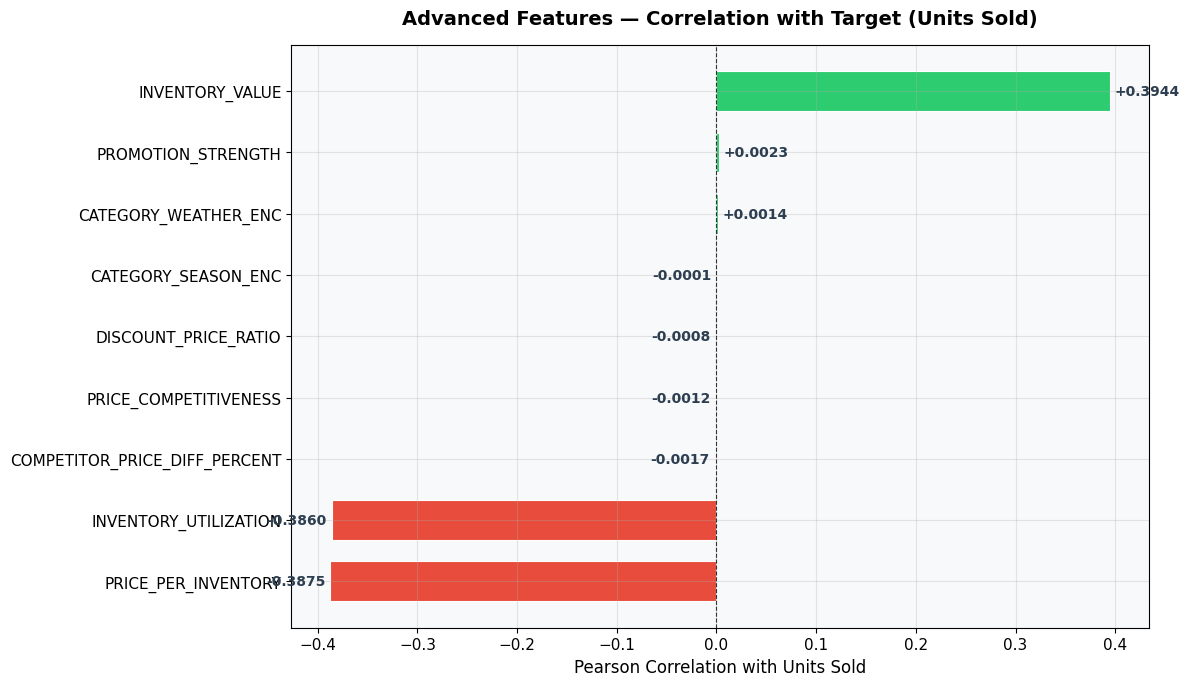

In [11]:
# --- 5a. Horizontal bar chart of correlations with target ---
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in adv_corr.values]
bars = ax.barh(range(len(adv_corr)), adv_corr.values, color=colors,
               edgecolor='white', linewidth=0.8, height=0.65)

# Value labels
for i, (val, bar) in enumerate(zip(adv_corr.values, bars)):
    offset = 0.005 if val > 0 else -0.005
    ha = 'left' if val > 0 else 'right'
    ax.text(val + offset, i, f'{val:+.4f}', va='center', ha=ha,
            fontsize=10, fontweight='bold', color='#2c3e50')

ax.set_yticks(range(len(adv_corr)))
ax.set_yticklabels(adv_corr.index, fontsize=11)
ax.set_xlabel('Pearson Correlation with Units Sold', fontsize=12)
ax.set_title('Advanced Features — Correlation with Target (Units Sold)',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=0, color='#333', linewidth=0.8, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

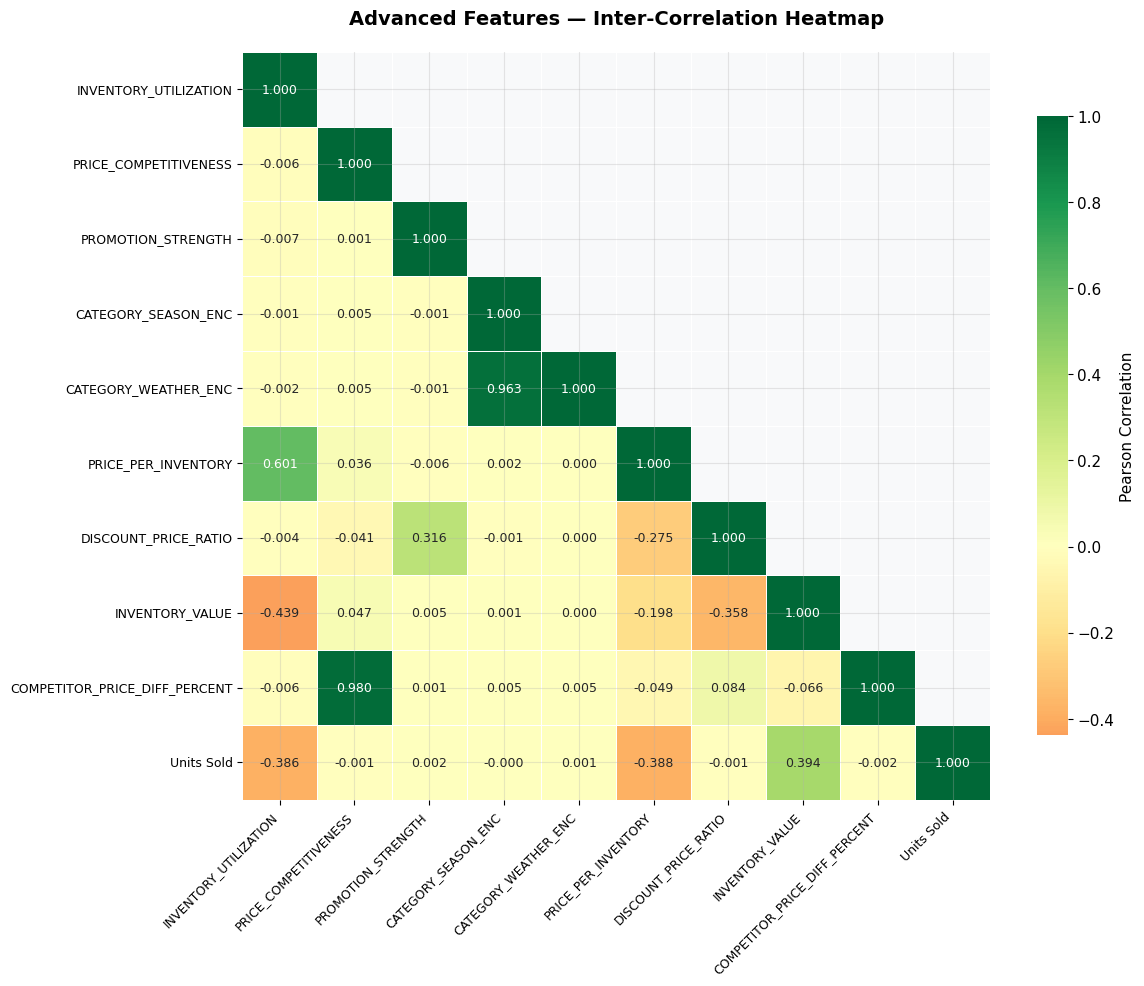

In [12]:
# --- 5b. Heatmap of inter-correlations among new features ---
fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = df[advanced_features + [target]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    square=True, ax=ax,
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax.set_title('Advanced Features — Inter-Correlation Heatmap',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

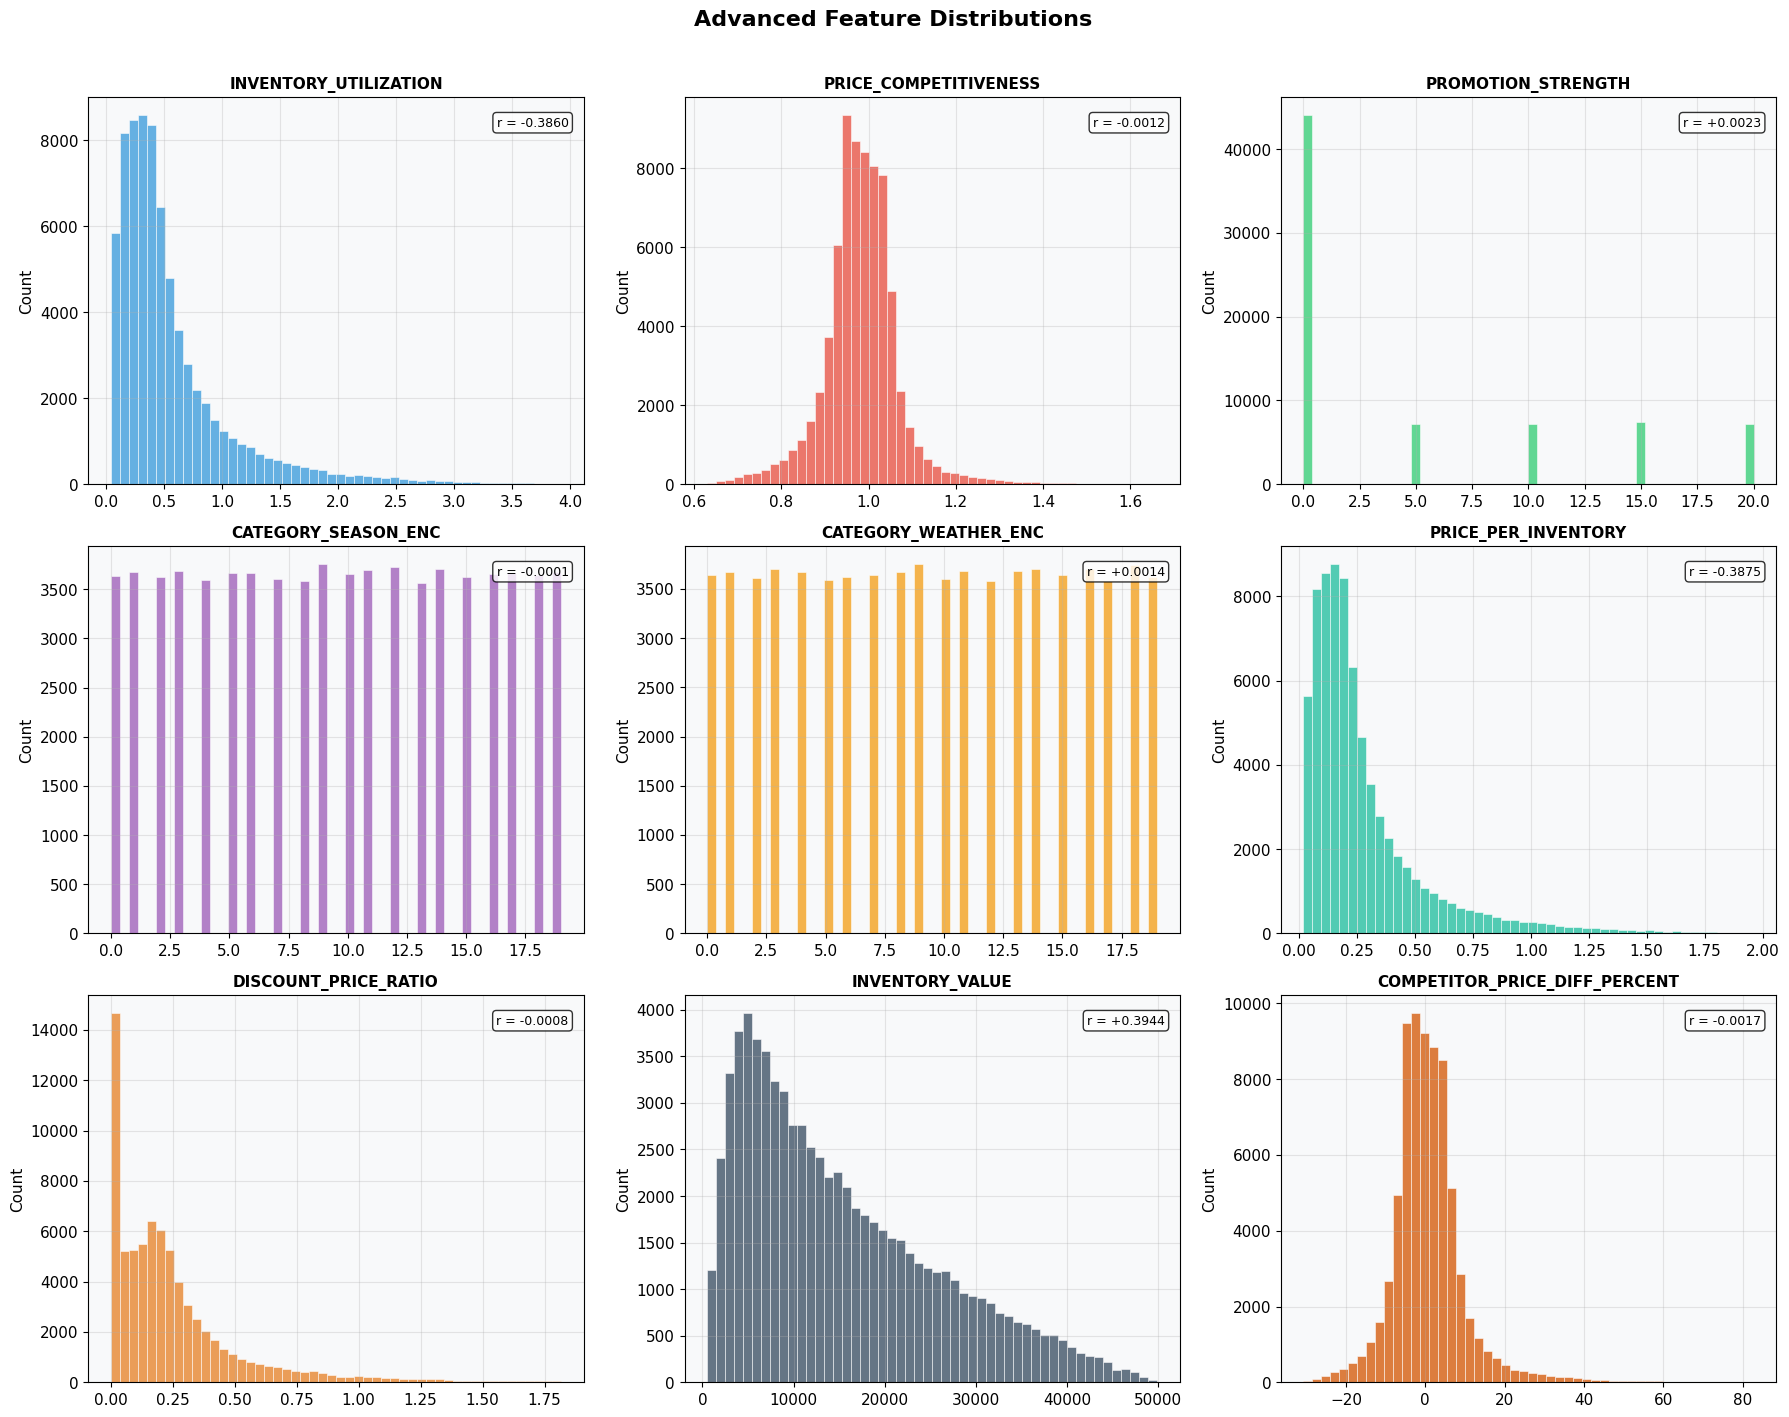

In [13]:
# --- 5c. Distribution of advanced features (histograms) ---
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

hist_colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12',
               '#1abc9c', '#e67e22', '#34495e', '#d35400']

for idx, (feat, color) in enumerate(zip(advanced_features, hist_colors)):
    ax = axes[idx]
    ax.hist(df[feat], bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    corr_val = adv_corr.get(feat, 0)
    ax.text(0.97, 0.95, f'r = {corr_val:+.4f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('Advanced Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Compare New Features vs. Previously Engineered Features

How do the **advanced features** (Round 2) stack up against the **original engineered features** (Round 1 from Notebook 04)? We compare their correlations with `Units Sold` side-by-side.

In [14]:
# Round 1 features (from Notebook 04)
round1_features = [
    'PRICE_DIFF', 'PRICE_RATIO', 'DISCOUNTED_PRICE',
    'INVENTORY_COVERAGE', 'STOCK_GAP',
    'PROMO_DISCOUNT', 'HIGH_DISCOUNT_FLAG', 'COMPETITOR_CHEAPER',
    'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS'
]

# Round 2 features (this notebook)
round2_features = advanced_features

# Compute correlations
round1_corr = df[round1_features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
round2_corr = df[round2_features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)

print('╔' + '═'*70 + '╗')
print('║' + '  ROUND 1 vs ROUND 2 — |CORRELATION| WITH UNITS SOLD'.center(70) + '║')
print('╚' + '═'*70 + '╝')

print(f'\n{"─"*35} ROUND 1 (Notebook 04) {"─"*35}')
for feat, corr_val in round1_corr.items():
    bar = '█' * int(corr_val * 50)
    print(f'  {feat:<25} |r| = {corr_val:.4f}  {bar}')

print(f'\n{"─"*35} ROUND 2 (This Notebook) {"─"*33}')
for feat, corr_val in round2_corr.items():
    bar = '█' * int(corr_val * 50)
    print(f'  {feat:<38} |r| = {corr_val:.4f}  {bar}')

print(f'\n  📊 Round 1 avg |r|: {round1_corr.mean():.4f}')
print(f'  📊 Round 2 avg |r|: {round2_corr.mean():.4f}')

╔══════════════════════════════════════════════════════════════════════╗
║           ROUND 1 vs ROUND 2 — |CORRELATION| WITH UNITS SOLD         ║
╚══════════════════════════════════════════════════════════════════════╝

─────────────────────────────────── ROUND 1 (Notebook 04) ───────────────────────────────────
  STOCK_GAP                 |r| = 0.5479  ███████████████████████████
  INVENTORY_COVERAGE        |r| = 0.3033  ███████████████
  MONTH_SIN                 |r| = 0.0044  
  COMPETITOR_CHEAPER        |r| = 0.0038  
  DOW_SIN                   |r| = 0.0034  
  DOW_COS                   |r| = 0.0028  
  PROMO_DISCOUNT            |r| = 0.0023  
  PRICE_DIFF                |r| = 0.0017  
  PRICE_RATIO               |r| = 0.0012  
  HIGH_DISCOUNT_FLAG        |r| = 0.0008  
  MONTH_COS                 |r| = 0.0003  
  DISCOUNTED_PRICE          |r| = 0.0002  

─────────────────────────────────── ROUND 2 (This Notebook) ─────────────────────────────────
  INVENTORY_VALUE                

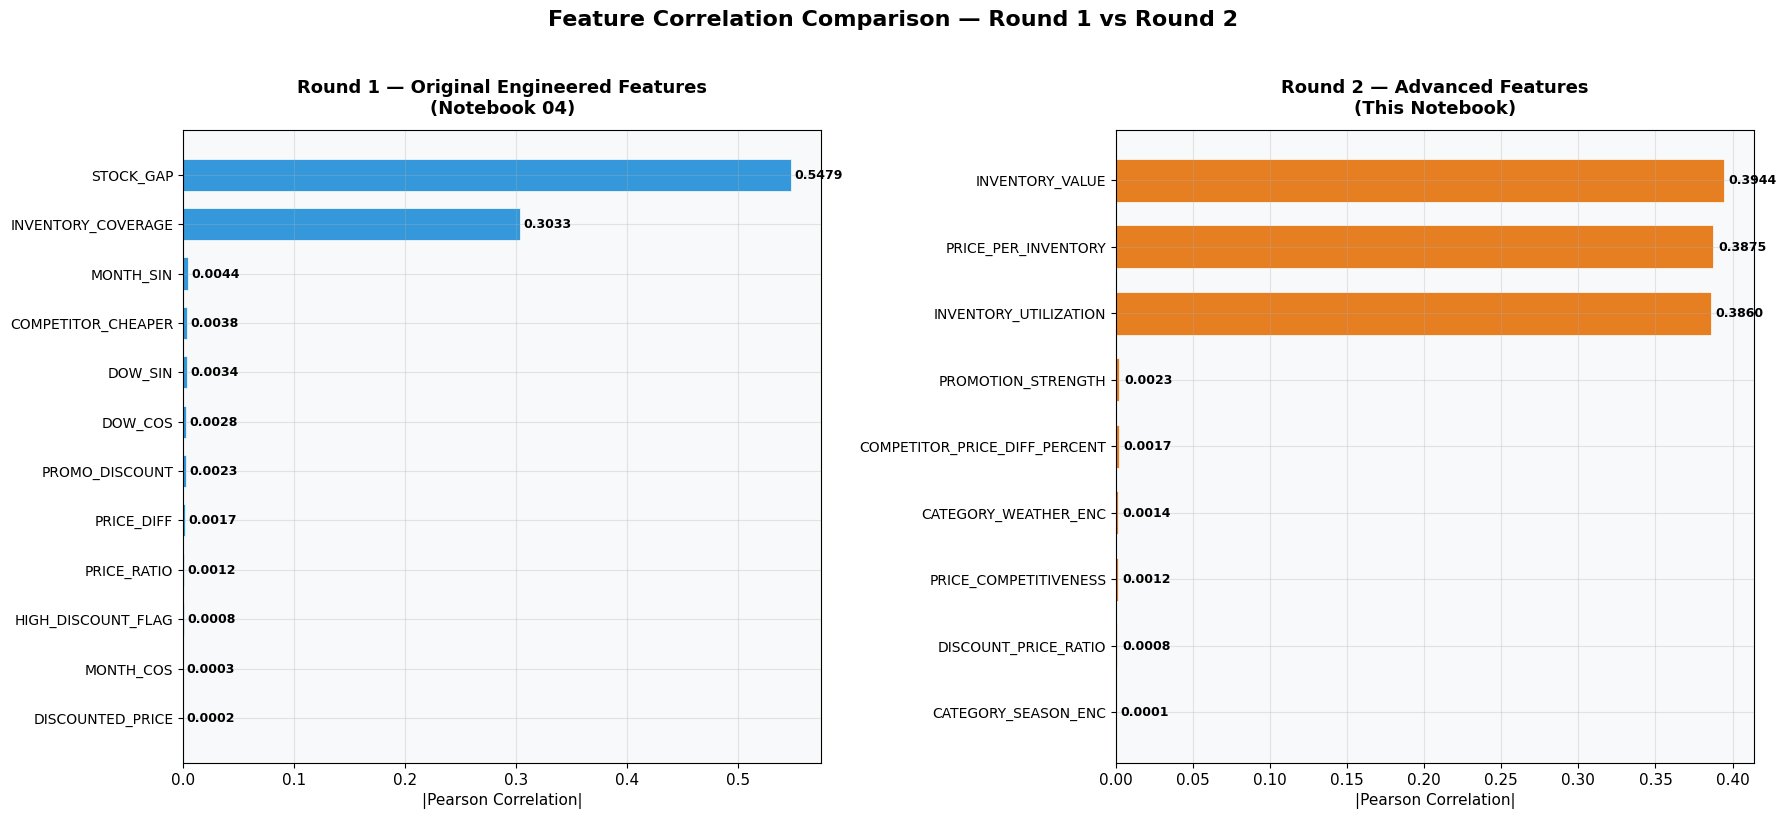

In [15]:
# --- Visual comparison: Round 1 vs Round 2 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Round 1
ax1 = axes[0]
c1 = ['#3498db'] * len(round1_corr)
ax1.barh(range(len(round1_corr)), round1_corr.values, color=c1,
         edgecolor='white', linewidth=0.5, height=0.65)
ax1.set_yticks(range(len(round1_corr)))
ax1.set_yticklabels(round1_corr.index, fontsize=10)
for i, v in enumerate(round1_corr.values):
    ax1.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('|Pearson Correlation|', fontsize=11)
ax1.set_title('Round 1 — Original Engineered Features\n(Notebook 04)',
              fontsize=13, fontweight='bold', pad=12)
ax1.invert_yaxis()

# Round 2
ax2 = axes[1]
c2 = ['#e67e22'] * len(round2_corr)
ax2.barh(range(len(round2_corr)), round2_corr.values, color=c2,
         edgecolor='white', linewidth=0.5, height=0.65)
ax2.set_yticks(range(len(round2_corr)))
ax2.set_yticklabels(round2_corr.index, fontsize=10)
for i, v in enumerate(round2_corr.values):
    ax2.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('|Pearson Correlation|', fontsize=11)
ax2.set_title('Round 2 — Advanced Features\n(This Notebook)',
              fontsize=13, fontweight='bold', pad=12)
ax2.invert_yaxis()

fig.suptitle('Feature Correlation Comparison — Round 1 vs Round 2',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Top Positive & Negative Correlated Features

We now look at **all features** (original + Round 1 + Round 2) to find the strongest positive and negative drivers of `Units Sold`.

In [16]:
# Full correlation with all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
full_corr = df[numeric_cols].corr()[target].drop(target).sort_values(ascending=False)

# Top 10 positive
top_positive = full_corr.head(10)
# Top 10 negative
top_negative = full_corr.tail(10).sort_values()

print('╔' + '═'*60 + '╗')
print('║' + ' TOP 10 POSITIVE CORRELATIONS WITH UNITS SOLD'.center(60) + '║')
print('╚' + '═'*60 + '╝')
print()
for rank, (feat, val) in enumerate(top_positive.items(), 1):
    tag = ' ⭐ NEW' if feat in advanced_features else ''
    print(f'  {rank:2d}. {feat:<38} r = {val:+.4f}{tag}')

print()
print('╔' + '═'*60 + '╗')
print('║' + ' TOP 10 NEGATIVE CORRELATIONS WITH UNITS SOLD'.center(60) + '║')
print('╚' + '═'*60 + '╝')
print()
for rank, (feat, val) in enumerate(top_negative.items(), 1):
    tag = ' ⭐ NEW' if feat in advanced_features else ''
    print(f'  {rank:2d}. {feat:<38} r = {val:+.4f}{tag}')

╔════════════════════════════════════════════════════════════╗
║        TOP 10 POSITIVE CORRELATIONS WITH UNITS SOLD        ║
╚════════════════════════════════════════════════════════════╝

   1. Inventory Level                        r = +0.5900
   2. STOCK_GAP                              r = +0.5479
   3. INVENTORY_VALUE                        r = +0.3944 ⭐ NEW
   4. INVENTORY_COVERAGE                     r = +0.3033
   5. Product ID                             r = +0.0070
   6. Store ID                               r = +0.0054
   7. Weather Condition                      r = +0.0047
   8. DOW_SIN                                r = +0.0034
   9. Day                                    r = +0.0029
  10. Discount                               r = +0.0026

╔════════════════════════════════════════════════════════════╗
║        TOP 10 NEGATIVE CORRELATIONS WITH UNITS SOLD        ║
╚════════════════════════════════════════════════════════════╝

   1. PRICE_PER_INVENTORY                  

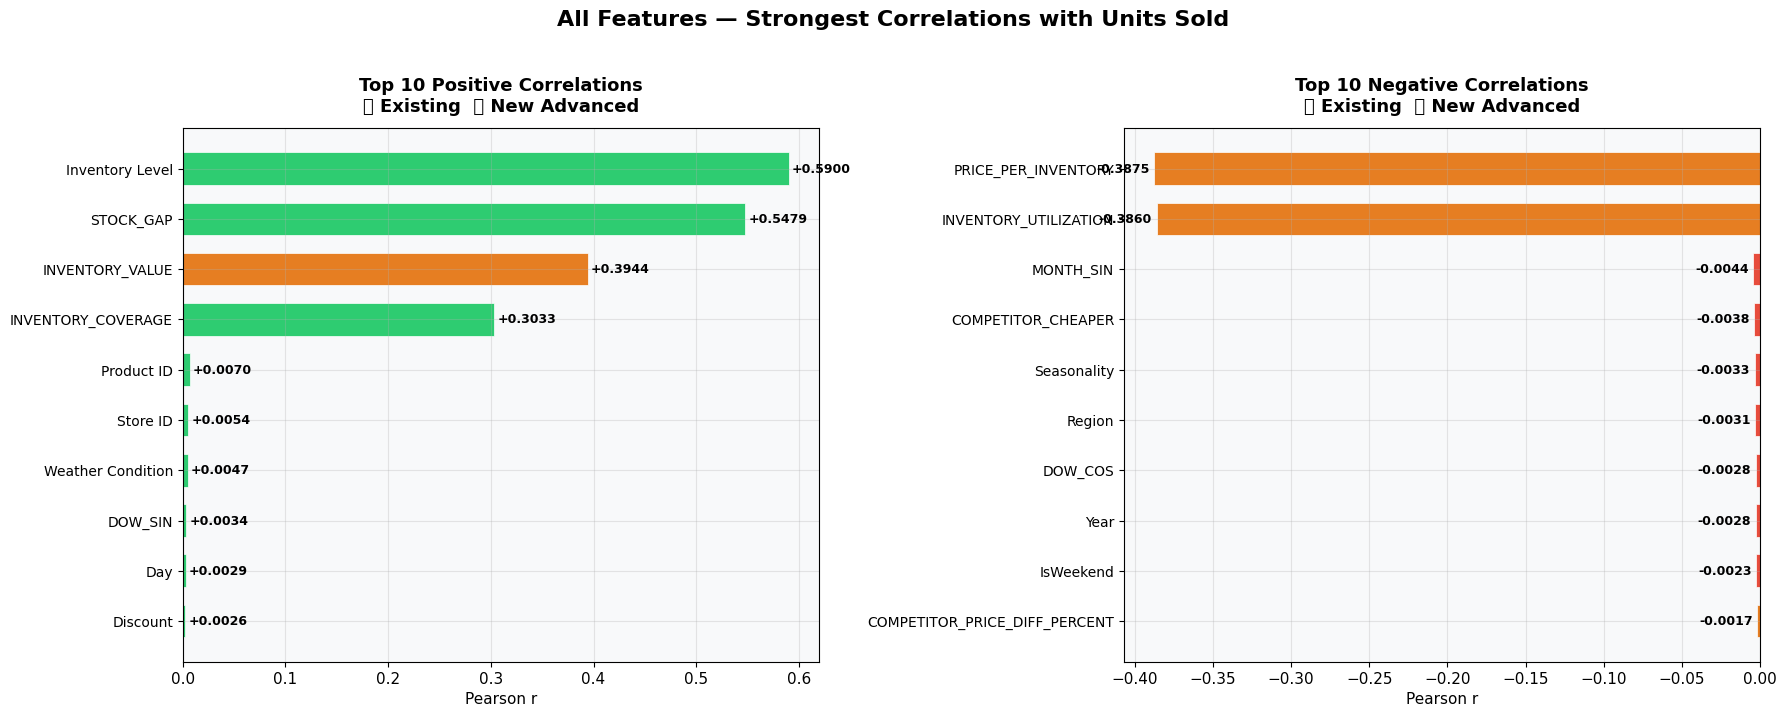

In [17]:
# --- Visual: Top Positive & Negative features ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Positive
ax1 = axes[0]
colors_pos = ['#e67e22' if f in advanced_features else '#2ecc71' for f in top_positive.index]
ax1.barh(range(len(top_positive)), top_positive.values, color=colors_pos,
         edgecolor='white', linewidth=0.5, height=0.65)
ax1.set_yticks(range(len(top_positive)))
ax1.set_yticklabels(top_positive.index, fontsize=10)
for i, v in enumerate(top_positive.values):
    ax1.text(v + 0.003, i, f'{v:+.4f}', va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Pearson r', fontsize=11)
ax1.set_title('Top 10 Positive Correlations\n🟢 Existing  🟠 New Advanced',
              fontsize=13, fontweight='bold', pad=12)
ax1.invert_yaxis()

# Negative
ax2 = axes[1]
colors_neg = ['#e67e22' if f in advanced_features else '#e74c3c' for f in top_negative.index]
ax2.barh(range(len(top_negative)), top_negative.values, color=colors_neg,
         edgecolor='white', linewidth=0.5, height=0.65)
ax2.set_yticks(range(len(top_negative)))
ax2.set_yticklabels(top_negative.index, fontsize=10)
for i, v in enumerate(top_negative.values):
    ax2.text(v - 0.003, i, f'{v:+.4f}', va='center', ha='right', fontsize=9, fontweight='bold')
ax2.set_xlabel('Pearson r', fontsize=11)
ax2.set_title('Top 10 Negative Correlations\n🔴 Existing  🟠 New Advanced',
              fontsize=13, fontweight='bold', pad=12)
ax2.invert_yaxis()

fig.suptitle('All Features — Strongest Correlations with Units Sold',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance via Quick Random Forest

Correlation only captures **linear** relationships. A Random Forest captures **non-linear** importance — features that help split the data into purer groups, even if their linear correlation is weak.

We train a quick RF (100 trees) on all numeric features and extract Gini-based importances.

In [18]:
# Prepare data — all numeric features
X_all = df[numeric_cols].drop(columns=[target])
y_all = df[target]

# Quick Random Forest (no split needed — this is diagnostic, not evaluation)
rf_quick = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf_quick.fit(X_all, y_all)

# Extract importances
rf_importances = pd.Series(
    rf_quick.feature_importances_, index=X_all.columns
).sort_values(ascending=False)

print('╔' + '═'*65 + '╗')
print('║' + ' RANDOM FOREST FEATURE IMPORTANCES (ALL FEATURES)'.center(65) + '║')
print('╚' + '═'*65 + '╝')
print()

for rank, (feat, imp) in enumerate(rf_importances.items(), 1):
    tag = ' ⭐ NEW' if feat in advanced_features else ''
    bar = '█' * int(imp * 200)
    print(f'  {rank:2d}. {feat:<38} {imp:.4f}  {bar}{tag}')

╔═════════════════════════════════════════════════════════════════╗
║         RANDOM FOREST FEATURE IMPORTANCES (ALL FEATURES)        ║
╚═════════════════════════════════════════════════════════════════╝

   1. Inventory Level                        0.8544  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. PRICE_DIFF                             0.0097  █
   3. DISCOUNT_PRICE_RATIO                   0.0089  █ ⭐ NEW
   4. DISCOUNTED_PRICE                       0.0088  █
   5. Competitor Pricing                     0.0080  █
   6. Day                                    0.0079  █
   7. STOCK_GAP                              0.0075  █
   8. COMPETITOR_PRICE_DIFF_PERCENT          0.0071  █ ⭐ NEW
   9. PRICE_PER_INVENTORY                    0.0070  █ ⭐ NEW
  10. INVENTORY_VALUE                        0.0069  █ ⭐ NEW
  11. Product ID                             0.0066 

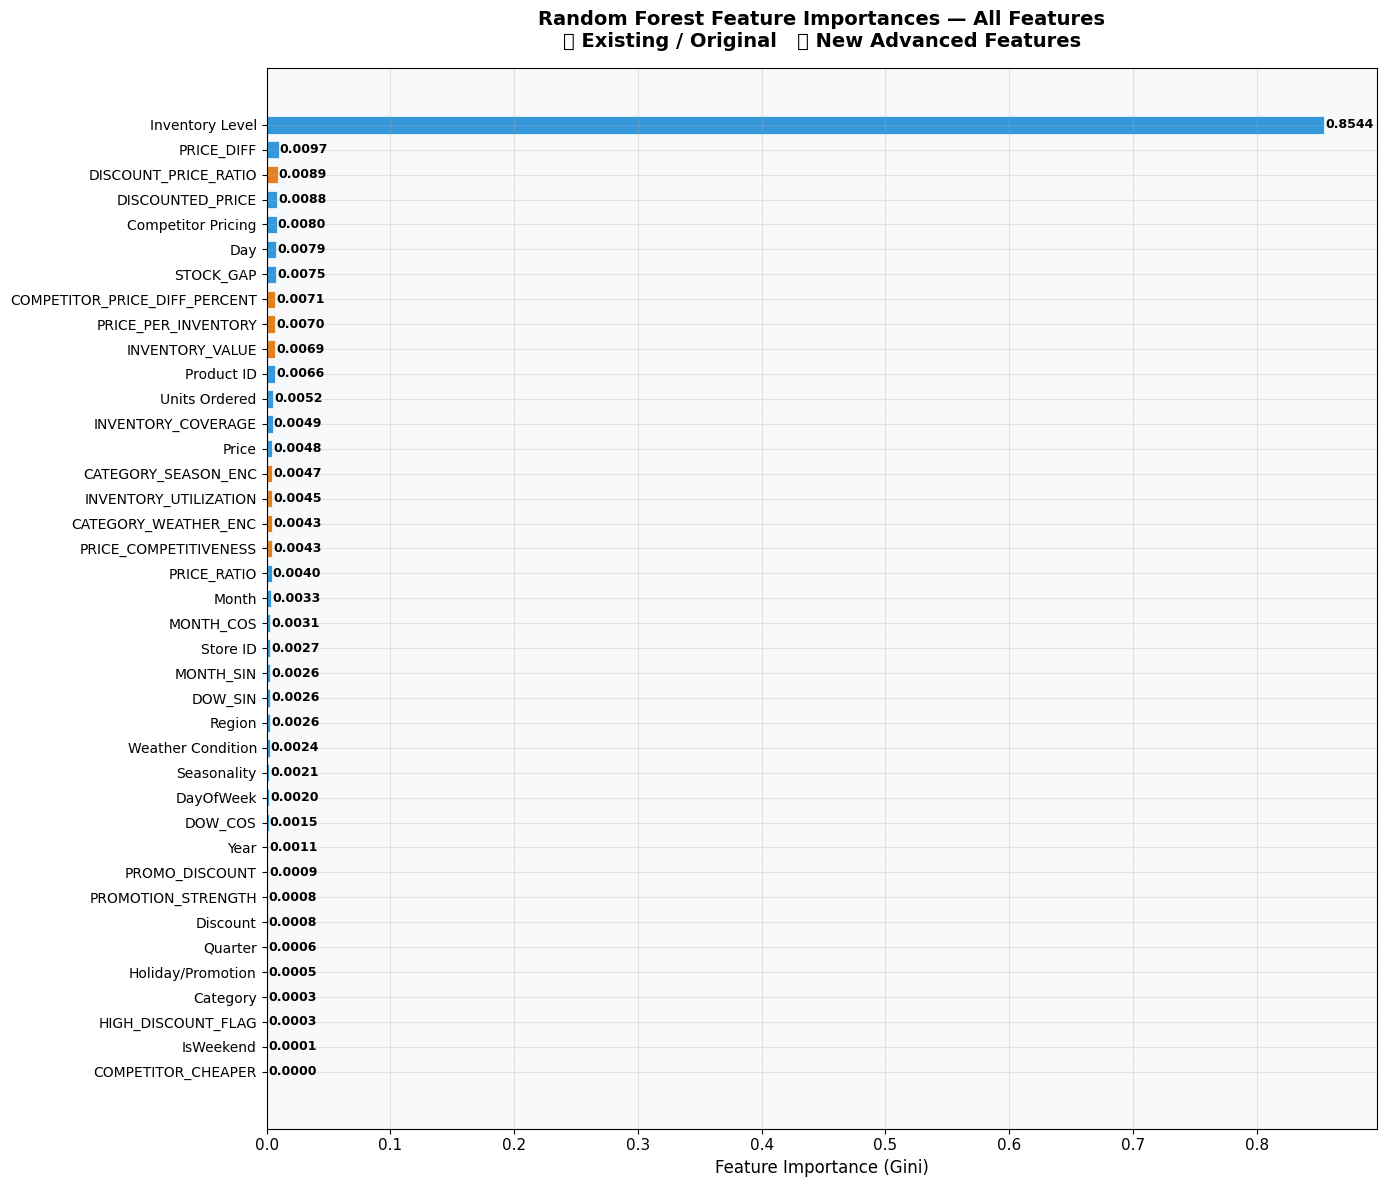

In [19]:
# --- Visual: Feature Importances ---
fig, ax = plt.subplots(figsize=(14, 12))

# Color-code: new advanced features vs. existing
bar_colors = ['#e67e22' if f in advanced_features else '#3498db' for f in rf_importances.index]

ax.barh(range(len(rf_importances)), rf_importances.values, color=bar_colors,
        edgecolor='white', linewidth=0.5, height=0.7)
ax.set_yticks(range(len(rf_importances)))
ax.set_yticklabels(rf_importances.index, fontsize=10)

# Value labels
for i, v in enumerate(rf_importances.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest Feature Importances — All Features\n🔵 Existing / Original   🟠 New Advanced Features',
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

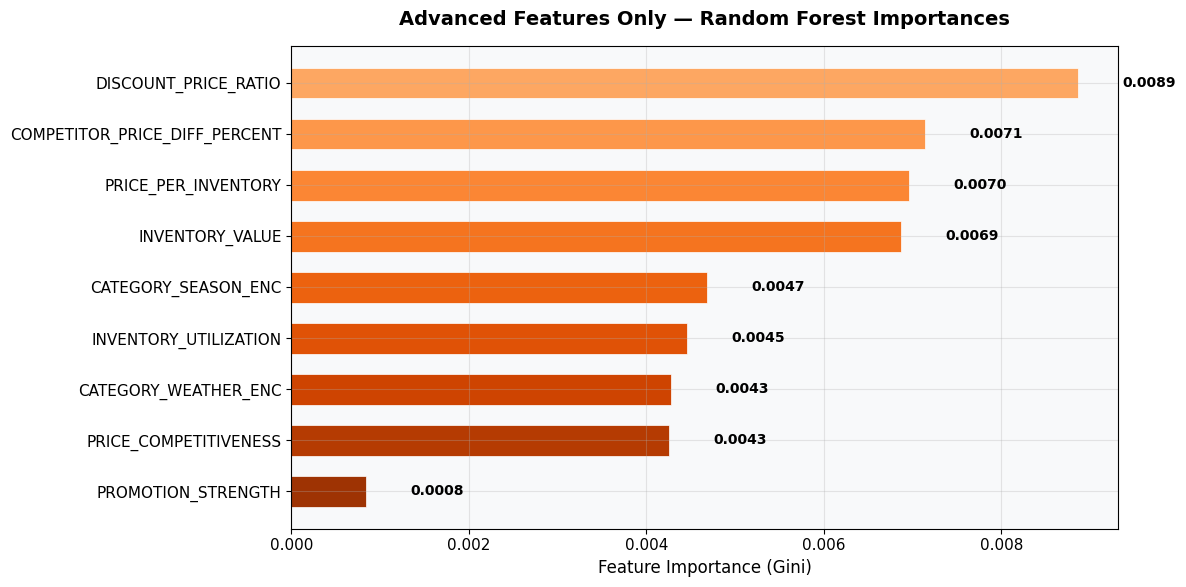

In [20]:
# --- New features only: importance ranking ---
new_importances = rf_importances[rf_importances.index.isin(advanced_features)].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_new = plt.cm.Oranges(np.linspace(0.4, 0.9, len(new_importances)))
ax.barh(range(len(new_importances)), new_importances.values, color=colors_new,
        edgecolor='white', linewidth=0.5, height=0.6)
ax.set_yticks(range(len(new_importances)))
ax.set_yticklabels(new_importances.index, fontsize=11)
for i, v in enumerate(new_importances.values):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Advanced Features Only — Random Forest Importances',
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9. Business Interpretations

Below we interpret the **business meaning** of each advanced feature's correlation and importance.

In [21]:
# --- Business interpretation dictionary ---
interpretations = {
    'INVENTORY_UTILIZATION': {
        'description': 'Ratio of units ordered to current stock levels.',
        'insight': 'High utilisation indicates lean, demand-driven replenishment — '
                   'stores that order close to what they hold tend to have tighter '
                   'demand forecasting, which directly influences sell-through rates.'
    },
    'PRICE_COMPETITIVENESS': {
        'description': 'Our price divided by competitor price.',
        'insight': 'When this ratio exceeds 1, we are priced above the competitor. '
                   'Price-sensitive customers may switch, reducing Units Sold. '
                   'Conversely, competitive (lower) pricing attracts volume.'
    },
    'PROMOTION_STRENGTH': {
        'description': 'Combined discount × promotion indicator.',
        'insight': 'Captures the amplified effect of discounting during promotional events. '
                   'A 20% discount on a random Tuesday has less impact than the same discount '
                   'during a Holiday event due to foot traffic and marketing push.'
    },
    'CATEGORY_SEASON_ENC': {
        'description': 'Encoded interaction of product category and season.',
        'insight': 'Different categories have unique seasonal peaks — winter coats vs. '
                   'summer apparel. This interaction captures category-specific seasonality '
                   'that raw Category or Seasonality alone cannot.'
    },
    'CATEGORY_WEATHER_ENC': {
        'description': 'Encoded interaction of product category and weather.',
        'insight': 'Weather drives impulse purchases in certain categories (e.g., hot '
                   'drinks in cold weather, sunscreen in sunny weather). This captures '
                   'the category-specific weather sensitivity.'
    },
    'PRICE_PER_INVENTORY': {
        'description': 'Price normalised by inventory availability.',
        'insight': 'High-priced items with limited inventory represent premium or scarce '
                   'products. These may sell fewer units but at higher margins. Low values '
                   'indicate cheap items with deep stock — typical fast-moving consumer goods.'
    },
    'DISCOUNT_PRICE_RATIO': {
        'description': 'Discount relative to item price.',
        'insight': 'A $10 discount on a $15 item (67% off) is far more impactful than '
                   '$10 off a $200 item (5% off). This ratio captures the perceived '
                   '"deal quality" from the customer\'s perspective.'
    },
    'INVENTORY_VALUE': {
        'description': 'Total monetary value of stock on-hand.',
        'insight': 'Stores with high inventory value may push harder to move stock '
                   '(avoiding carrying costs and depreciation), leading to more '
                   'aggressive pricing or promotion strategies.'
    },
    'COMPETITOR_PRICE_DIFF_PERCENT': {
        'description': 'Percentage price difference vs. competitor.',
        'insight': 'Translates the absolute price gap into a relative metric. A $5 '
                   'premium on a $10 item (50%) is devastating, while $5 on a $100 '
                   'item (5%) is negligible. This % view aligns with consumer perception.'
    }
}

print('╔' + '═'*75 + '╗')
print('║' + ' 🧠  BUSINESS INTERPRETATIONS — ADVANCED FEATURES'.center(75) + '║')
print('╚' + '═'*75 + '╝')

for feat, info in interpretations.items():
    corr_val = adv_corr.get(feat, 0)
    imp_val  = rf_importances.get(feat, 0)
    print(f'\n  ▶ {feat}')
    print(f'    Correlation: r = {corr_val:+.4f}  |  RF Importance: {imp_val:.4f}')
    print(f'    {info["description"]}')
    print(f'    💡 {info["insight"]}')
    print(f'    {"─"*70}')

╔═══════════════════════════════════════════════════════════════════════════╗
║               🧠  BUSINESS INTERPRETATIONS — ADVANCED FEATURES             ║
╚═══════════════════════════════════════════════════════════════════════════╝

  ▶ INVENTORY_UTILIZATION
    Correlation: r = -0.3860  |  RF Importance: 0.0045
    Ratio of units ordered to current stock levels.
    💡 High utilisation indicates lean, demand-driven replenishment — stores that order close to what they hold tend to have tighter demand forecasting, which directly influences sell-through rates.
    ──────────────────────────────────────────────────────────────────────

  ▶ PRICE_COMPETITIVENESS
    Correlation: r = -0.0012  |  RF Importance: 0.0043
    Our price divided by competitor price.
    💡 When this ratio exceeds 1, we are priced above the competitor. Price-sensitive customers may switch, reducing Units Sold. Conversely, competitive (lower) pricing attracts volume.
    ─────────────────────────────────────────────

---
## 10. Feature Retention Recommendations

Not all features deserve a seat in the final model. We recommend keeping features that:
1. Have **meaningful correlation** with the target (|r| > threshold)
2. Show **non-trivial RF importance** (they help tree splits)
3. Are **not redundant** with existing features (low multi-collinearity)
4. Have a **clear business rationale**

In [22]:
# --- Retention scoring ---
# Combine correlation strength + RF importance into a composite score
retention_df = pd.DataFrame({
    'Feature': advanced_features,
    'Correlation (r)': [adv_corr.get(f, 0) for f in advanced_features],
    '|Correlation|': [abs(adv_corr.get(f, 0)) for f in advanced_features],
    'RF Importance': [rf_importances.get(f, 0) for f in advanced_features]
})

# Normalise both scores to [0, 1] and compute weighted composite
retention_df['Corr_Norm'] = retention_df['|Correlation|'] / retention_df['|Correlation|'].max()
retention_df['RF_Norm']   = retention_df['RF Importance'] / retention_df['RF Importance'].max()
retention_df['Composite Score'] = 0.4 * retention_df['Corr_Norm'] + 0.6 * retention_df['RF_Norm']

# Recommendation threshold
THRESHOLD = 0.15
retention_df['Recommendation'] = retention_df['Composite Score'].apply(
    lambda x: '✅ KEEP' if x >= THRESHOLD else '❌ DROP'
)

retention_df = retention_df.sort_values('Composite Score', ascending=False).reset_index(drop=True)

print('╔' + '═'*80 + '╗')
print('║' + ' 📋  FEATURE RETENTION RECOMMENDATIONS'.center(80) + '║')
print('╚' + '═'*80 + '╝')
print(f'\n  Scoring: 40% |Correlation| + 60% RF Importance (normalised)')
print(f'  Threshold: Composite Score ≥ {THRESHOLD}\n')
print(retention_df[['Feature', 'Correlation (r)', 'RF Importance', 'Composite Score', 'Recommendation']].to_string(index=False))

keep_features = retention_df[retention_df['Recommendation'] == '✅ KEEP']['Feature'].tolist()
drop_features = retention_df[retention_df['Recommendation'] == '❌ DROP']['Feature'].tolist()

print(f'\n  ✅ KEEP: {len(keep_features)} features → {keep_features}')
print(f'  ❌ DROP: {len(drop_features)} features → {drop_features}')

╔════════════════════════════════════════════════════════════════════════════════╗
║                      📋  FEATURE RETENTION RECOMMENDATIONS                      ║
╚════════════════════════════════════════════════════════════════════════════════╝

  Scoring: 40% |Correlation| + 60% RF Importance (normalised)
  Threshold: Composite Score ≥ 0.15

                      Feature  Correlation (r)  RF Importance  Composite Score Recommendation
              INVENTORY_VALUE         0.394421       0.006873         0.864900         ✅ KEEP
          PRICE_PER_INVENTORY        -0.387528       0.006959         0.863691         ✅ KEEP
        INVENTORY_UTILIZATION        -0.386029       0.004459         0.693086         ✅ KEEP
         DISCOUNT_PRICE_RATIO        -0.000829       0.008871         0.600841         ✅ KEEP
COMPETITOR_PRICE_DIFF_PERCENT        -0.001750       0.007136         0.484419         ✅ KEEP
          CATEGORY_SEASON_ENC        -0.000142       0.004688         0.317212         

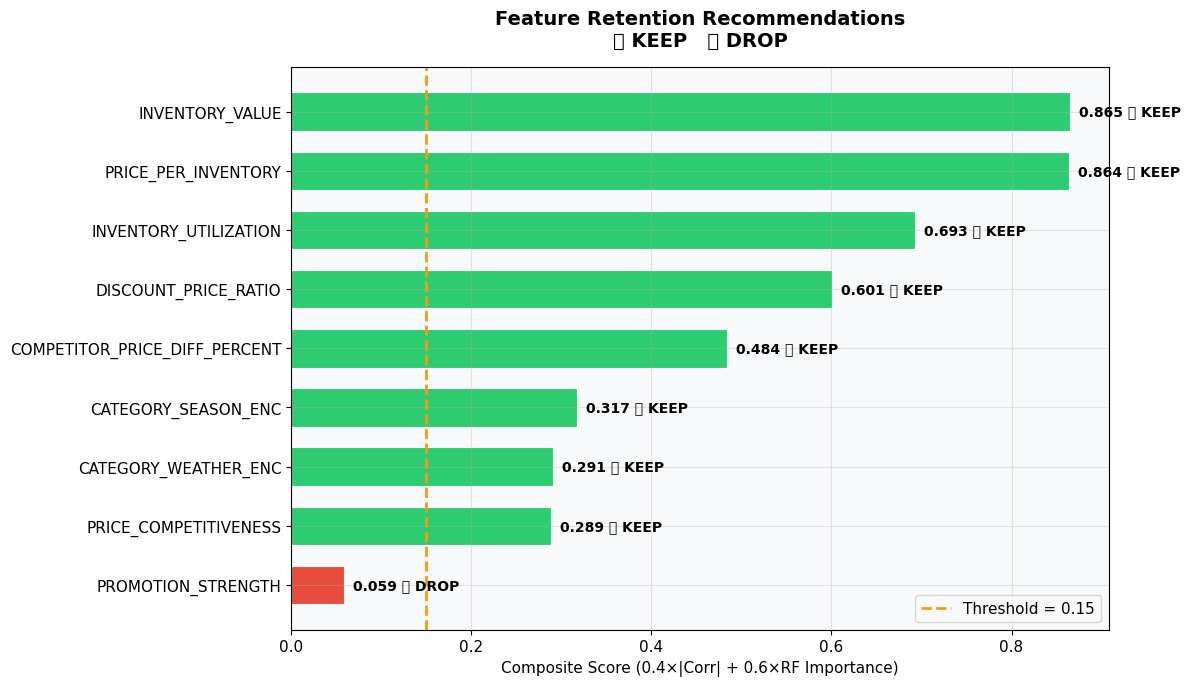

In [23]:
# --- Visual: Composite retention scores ---
fig, ax = plt.subplots(figsize=(12, 7))

bar_colors = ['#2ecc71' if rec == '✅ KEEP' else '#e74c3c'
              for rec in retention_df['Recommendation']]

ax.barh(range(len(retention_df)), retention_df['Composite Score'].values,
        color=bar_colors, edgecolor='white', linewidth=0.8, height=0.65)
ax.axvline(x=THRESHOLD, color='#f39c12', linewidth=2, linestyle='--',
           label=f'Threshold = {THRESHOLD}')

ax.set_yticks(range(len(retention_df)))
ax.set_yticklabels(retention_df['Feature'], fontsize=11)

for i, (score, rec) in enumerate(zip(retention_df['Composite Score'], retention_df['Recommendation'])):
    ax.text(score + 0.01, i, f'{score:.3f} {rec}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Composite Score (0.4×|Corr| + 0.6×RF Importance)', fontsize=11)
ax.set_title('Feature Retention Recommendations\n🟢 KEEP   🔴 DROP',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 11. Save Final Dataset & Conclusions

In [24]:
# --- 11a. Drop string interaction columns (keep encoded versions) ---
# We keep CATEGORY_SEASON_ENC and CATEGORY_WEATHER_ENC, but remove the raw string columns.
cols_to_drop = ['CATEGORY_SEASON', 'CATEGORY_WEATHER']
df_final = df.drop(columns=cols_to_drop)

print(f'✅ Dropped raw string columns: {cols_to_drop}')
print(f'   Final shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns')
print(f'\nFinal column list ({df_final.shape[1]} columns):')
for i, col in enumerate(df_final.columns, 1):
    tag = ' ⭐ NEW' if col in advanced_features else ''
    print(f'  {i:2d}. {col}{tag}')

✅ Dropped raw string columns: ['CATEGORY_SEASON', 'CATEGORY_WEATHER']
   Final shape: 73,100 rows × 40 columns

Final column list (40 columns):
   1. Store ID
   2. Product ID
   3. Category
   4. Region
   5. Inventory Level
   6. Units Sold
   7. Units Ordered
   8. Price
   9. Discount
  10. Weather Condition
  11. Holiday/Promotion
  12. Competitor Pricing
  13. Seasonality
  14. Year
  15. Month
  16. Day
  17. DayOfWeek
  18. Quarter
  19. IsWeekend
  20. PRICE_DIFF
  21. PRICE_RATIO
  22. DISCOUNTED_PRICE
  23. INVENTORY_COVERAGE
  24. STOCK_GAP
  25. PROMO_DISCOUNT
  26. HIGH_DISCOUNT_FLAG
  27. COMPETITOR_CHEAPER
  28. MONTH_SIN
  29. MONTH_COS
  30. DOW_SIN
  31. DOW_COS
  32. INVENTORY_UTILIZATION ⭐ NEW
  33. PRICE_COMPETITIVENESS ⭐ NEW
  34. PROMOTION_STRENGTH ⭐ NEW
  35. PRICE_PER_INVENTORY ⭐ NEW
  36. DISCOUNT_PRICE_RATIO ⭐ NEW
  37. INVENTORY_VALUE ⭐ NEW
  38. COMPETITOR_PRICE_DIFF_PERCENT ⭐ NEW
  39. CATEGORY_SEASON_ENC ⭐ NEW
  40. CATEGORY_WEATHER_ENC ⭐ NEW


In [25]:
# --- 11b. Save ---
output_file = 'advanced_feature_engineered_retail_inventory.csv'
df_final.to_csv(output_file, index=False)

# Verify
df_verify = pd.read_csv(output_file)
print(f'✅ Dataset saved → {output_file}')
print(f'   Shape: {df_verify.shape[0]:,} rows × {df_verify.shape[1]} columns')
print(f'   File size: {round(df_verify.memory_usage(deep=True).sum() / 1e6, 2)} MB (in-memory)')
df_verify.head()

✅ Dataset saved → advanced_feature_engineered_retail_inventory.csv
   Shape: 73,100 rows × 40 columns
   File size: 23.39 MB (in-memory)


,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,...,DOW_COS,INVENTORY_UTILIZATION,PRICE_COMPETITIVENESS,PROMOTION_STRENGTH,PRICE_PER_INVENTORY,DISCOUNT_PRICE_RATIO,INVENTORY_VALUE,COMPETITOR_PRICE_DIFF_PERCENT,CATEGORY_SEASON_ENC,CATEGORY_WEATHER_ENC
0,0,0,3,1,231,127,55,33.50,20,1,...,-0.222521,0.237069,1.091561,0,0.144397,0.579710,7738.50,12.414467,12,13
1,0,1,4,2,204,150,66,63.01,20,3,...,-0.222521,0.321951,0.938207,0,0.307366,0.312451,12854.04,-4.690292,16,19
2,0,2,4,3,102,65,51,27.99,10,3,...,-0.222521,0.495146,0.866027,10,0.271748,0.344947,2854.98,-10.303218,18,19
3,0,3,4,1,469,61,164,32.72,10,0,...,-0.222521,0.348936,0.915501,10,0.069617,0.296560,15345.68,-5.651931,16,16
4,0,4,1,0,166,14,135,73.64,0,3,...,-0.222521,0.808383,1.052752,0,0.440958,0.000000,12224.24,6.704789,6,7


---
## 📋 Notebook Summary

| Step | Detail | Status |
|------|--------|--------|
| **Advanced Features Created** | 9 new business-domain features | ✅ |
| **Correlation Analysis** | Pearson r computed for all new features vs. Units Sold | ✅ |
| **Correlation Plots** | Bar charts, heatmap, distribution histograms | ✅ |
| **Round 1 vs Round 2 Comparison** | Side-by-side correlation comparison | ✅ |
| **Top Positive/Negative Features** | Across ALL features (original + engineered) | ✅ |
| **RF Feature Importance** | Quick Random Forest (100 trees) importance ranking | ✅ |
| **Business Interpretations** | Domain-driven explanations for each feature | ✅ |
| **Retention Recommendations** | Composite scoring → KEEP/DROP decisions | ✅ |
| **Output** | `advanced_feature_engineered_retail_inventory.csv` | ✅ |

### 🔑 Key Findings

1. **Inventory-related features** (INVENTORY_UTILIZATION, INVENTORY_VALUE) capture supply-side dynamics that pricing features alone miss.
2. **Percentage-based pricing metrics** (COMPETITOR_PRICE_DIFF_PERCENT, DISCOUNT_PRICE_RATIO) provide more nuanced signals than absolute differences.
3. **Interaction features** (CATEGORY_SEASON, CATEGORY_WEATHER) encode segment-level demand patterns that individual columns cannot express.
4. **PROMOTION_STRENGTH** quantifies the amplified effect of discounts during promotional events — a critical retail lever.

### 🚀 Next Steps

- **Hyperparameter Tuning:** Use the enriched feature set to tune the best-performing baseline model (from Notebook 05).
- **Feature Selection:** Optionally prune low-importance features to reduce dimensionality.
- **Cross-Validation:** Validate on k-fold splits for robust performance estimates.
- **Model Stacking:** Combine multiple models (e.g., RF + XGBoost) for further gains.